# Task 2 — Model Building & Training
**Adey Innovations Inc. | Fraud Detection Project**

Two independent pipelines:
- **Fraud_Data.csv** — E-commerce transactions (151,112 rows, 9.37% fraud)
- **creditcard.csv** — Bank credit card transactions (284,807 rows, 0.17% fraud)

**Steps:** Stratified split → SMOTE (train only) → Logistic Regression (baseline) → XGBoost (ensemble) → 5-Fold CV → AUC-PR, F1, Confusion Matrix → Save models

**Note on metrics:** Standard accuracy is misleading on imbalanced data. A model predicting all-legitimate achieves 99.83% accuracy on creditcard — we use **AUC-PR (primary)** and **F1-Score** instead.

## 1. Setup & Imports

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, f1_score,
    precision_recall_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from src.data_preprocessing import build_fraud_pipeline, build_creditcard_pipeline

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

MODELS = "../models/"
os.makedirs(MODELS, exist_ok=True)
print("Setup complete")

Setup complete


## 2. Load Data & Stratified Train-Test Split

Using `build_fraud_pipeline()` and `build_creditcard_pipeline()` from `src/data_preprocessing.py` for all cleaning, geolocation, feature engineering and scaling. Then applying **stratified** `train_test_split` to preserve the exact fraud ratio in both splits.

In [1]:
# ── Fraud_Data ──────────────────────────────────────────────────────────────
X_fd, y_fd, scaler_fd = build_fraud_pipeline(
    "../data/raw/Fraud_Data.csv",
    "../data/raw/IpAddress_to_Country.csv"
)

X_train_fd, X_test_fd, y_train_fd, y_test_fd = train_test_split(
    X_fd, y_fd, test_size=0.2, stratify=y_fd, random_state=42
)

print("Fraud_Data — Stratified Train-Test Split:")
print(f"  Train: {X_train_fd.shape[0]:,} rows | fraud rate: {y_train_fd.mean():.3%}")
print(f"  Test : {X_test_fd.shape[0]:,} rows  | fraud rate: {y_test_fd.mean():.3%}")
print(f"  Class ratio preserved: train={y_train_fd.mean():.4f}  test={y_test_fd.mean():.4f}")

# ── CreditCard ────────────────────────────────────────────────────────────────
X_cc, y_cc, scaler_cc = build_creditcard_pipeline("../data/raw/creditcard.csv")

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, stratify=y_cc, random_state=42
)

print("\ncreditcard — Stratified Train-Test Split:")
print(f"  Train: {X_train_cc.shape[0]:,} rows | fraud rate: {y_train_cc.mean():.4%}")
print(f"  Test : {X_test_cc.shape[0]:,} rows  | fraud rate: {y_test_cc.mean():.4%}")

Fraud_Data — Stratified Train-Test Split:
  Train: 120,889 rows | fraud rate: 9.365%
  Test : 30,223 rows  | fraud rate: 9.364%
  Class ratio preserved: train=0.0936  test=0.0936

creditcard — Stratified Train-Test Split:
  Train: 226,980 rows | fraud rate: 0.1665%
  Test : 56,746 rows  | fraud rate: 0.1674%


## 3. SMOTE — Training Set Only

SMOTE generates synthetic minority-class samples **in the training set only**. The test set is never resampled — it keeps the real-world distribution.

In [1]:
smote = SMOTE(random_state=42, k_neighbors=5)

X_train_fd_r, y_train_fd_r = smote.fit_resample(X_train_fd, y_train_fd)
X_train_cc_r, y_train_cc_r = smote.fit_resample(X_train_cc, y_train_cc)

print("After SMOTE (training set only):")
print(f"  Fraud_Data: {(y_train_fd_r==0).sum():,} legit / {(y_train_fd_r==1).sum():,} fraud")
print(f"  CreditCard: {(y_train_cc_r==0).sum():,} legit / {(y_train_cc_r==1).sum():,} fraud")
print("  Test sets: UNCHANGED — real-world distribution preserved")

After SMOTE (training set only):
  Fraud_Data: 109,568 legit / 109,568 fraud
  CreditCard: 226,602 legit / 226,602 fraud
  Test sets: UNCHANGED — real-world distribution preserved


## 4. Evaluation Helper

In [1]:
def evaluate(name, model, X_test, y_test, dataset):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_pr  = average_precision_score(y_test, y_prob)
    f1      = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm      = confusion_matrix(y_test, y_pred)
    sep = "=" * 55
    print(f"\n{sep}")
    print(f"  {name} | {dataset}")
    print(f"  AUC-PR : {auc_pr:.4f}  <-- PRIMARY METRIC")
    print(f"  F1     : {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Legit','Fraud'])}")
    print(f"  Confusion Matrix:\n{cm}")
    return {"model": name, "dataset": dataset,
            "AUC-PR": round(auc_pr,4), "F1": round(f1,4), "ROC-AUC": round(roc_auc,4),
            "TP": int(cm[1,1]), "FP": int(cm[0,1]),
            "TN": int(cm[0,0]), "FN": int(cm[1,0])}

print("Evaluation helper ready.")

Evaluation helper ready.


## 5. Logistic Regression — Fraud_Data (Baseline)

In [1]:
lr_fd = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_fd.fit(X_train_fd_r, y_train_fd_r)
print("Logistic Regression (Fraud_Data) trained.")
res_lr_fd = evaluate("Logistic Regression", lr_fd, X_test_fd, y_test_fd, "Fraud_Data")

Logistic Regression (Fraud_Data) trained.

  Logistic Regression | Fraud_Data
  AUC-PR : 0.6200  <-- PRIMARY METRIC
  F1     : 0.6814
  ROC-AUC: 0.7705

              precision    recall  f1-score   support

       Legit       0.95      1.00      0.98     27393
       Fraud       0.96      0.53      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.96      0.76      0.83     30223
weighted avg       0.95      0.95      0.95     30223

  Confusion Matrix:
[[27330    63]
 [ 1335  1495]]


## 6. XGBoost — Fraud_Data (Ensemble)

Hyperparameters: `n_estimators=200`, `max_depth=6`, `learning_rate=0.1`, `subsample=0.8`, `colsample_bytree=0.8`, `scale_pos_weight` for imbalance.

In [1]:
spw_fd = int((y_train_fd_r==0).sum() / (y_train_fd_r==1).sum())
print(f"scale_pos_weight: {spw_fd}")

xgb_fd = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_fd, eval_metric="aucpr",
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_fd.fit(X_train_fd_r, y_train_fd_r)
print("XGBoost (Fraud_Data) trained.")
res_xgb_fd = evaluate("XGBoost", xgb_fd, X_test_fd, y_test_fd, "Fraud_Data")

scale_pos_weight: 1
XGBoost (Fraud_Data) trained.

  XGBoost | Fraud_Data
  AUC-PR : 0.5881  <-- PRIMARY METRIC
  F1     : 0.6686
  ROC-AUC: 0.7640

              precision    recall  f1-score   support

       Legit       0.95      0.99      0.97     27393
       Fraud       0.90      0.53      0.67      2830

    accuracy                           0.95     30223
   macro avg       0.93      0.76      0.82     30223
weighted avg       0.95      0.95      0.94     30223

  Confusion Matrix:
[[27232   161]
 [ 1328  1502]]


## 7. Logistic Regression — CreditCard (Baseline)

In [1]:
lr_cc = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_cc.fit(X_train_cc_r, y_train_cc_r)
print("Logistic Regression (CreditCard) trained.")
res_lr_cc = evaluate("Logistic Regression", lr_cc, X_test_cc, y_test_cc, "CreditCard")

Logistic Regression (CreditCard) trained.

  Logistic Regression | CreditCard
  AUC-PR : 0.6768  <-- PRIMARY METRIC
  F1     : 0.1002
  ROC-AUC: 0.9619

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

  Confusion Matrix:
[[55172  1479]
 [   12    83]]


## 8. XGBoost — CreditCard (Ensemble)

In [1]:
spw_cc = int((y_train_cc_r==0).sum() / (y_train_cc_r==1).sum())
print(f"scale_pos_weight: {spw_cc}")

xgb_cc = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_cc, eval_metric="aucpr",
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_cc.fit(X_train_cc_r, y_train_cc_r)
print("XGBoost (CreditCard) trained.")
res_xgb_cc = evaluate("XGBoost", xgb_cc, X_test_cc, y_test_cc, "CreditCard")

scale_pos_weight: 1
XGBoost (CreditCard) trained.

  XGBoost | CreditCard
  AUC-PR : 0.8120  <-- PRIMARY METRIC
  F1     : 0.7136
  ROC-AUC: 0.9751

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.64      0.80      0.71        95

    accuracy                           1.00     56746
   macro avg       0.82      0.90      0.86     56746
weighted avg       1.00      1.00      1.00     56746

  Confusion Matrix:
[[56609    42]
 [   19    76]]


## 9. Save Models to models/

All trained models persisted with `joblib` for Task 3 (SHAP) and future inference.

In [1]:
joblib.dump(lr_fd,     MODELS + "lr_fraud.pkl")
joblib.dump(xgb_fd,    MODELS + "xgb_fraud.pkl")
joblib.dump(lr_cc,     MODELS + "lr_creditcard.pkl")
joblib.dump(xgb_cc,    MODELS + "xgb_creditcard.pkl")
joblib.dump(scaler_fd, MODELS + "scaler_fraud.pkl")
joblib.dump(scaler_cc, MODELS + "scaler_creditcard.pkl")

print("Saved to models/:")
for f in sorted(os.listdir(MODELS)):
    if f.endswith(".pkl"):
        print(f"  {f:<35} {os.path.getsize(MODELS+f):>10,} bytes")

Saved to models/:
  lr_creditcard.pkl                       1,535 bytes
  lr_fraud.pkl                            6,751 bytes
  scaler_creditcard.pkl                     903 bytes
  scaler_fraud.pkl                        1,087 bytes
  xgb_creditcard.pkl                    656,967 bytes
  xgb_fraud.pkl                         565,908 bytes


## 10. 5-Fold Stratified Cross-Validation

More reliable than a single test split — reports mean +/- std across 5 folds.

In [1]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Stratified CV Results:")
print(f"{'Model':<23} {'Dataset':<12} {'CV AUC-PR':<22} {'CV F1'}")
print("-" * 72)

for name, model, X, y, ds in [
    ("Logistic Regression", lr_fd,  X_train_fd_r, y_train_fd_r, "Fraud_Data"),
    ("XGBoost",             xgb_fd, X_train_fd_r, y_train_fd_r, "Fraud_Data"),
    ("Logistic Regression", lr_cc,  X_train_cc_r, y_train_cc_r, "CreditCard"),
    ("XGBoost",             xgb_cc, X_train_cc_r, y_train_cc_r, "CreditCard"),
]:
    s = cross_validate(model, X, y, cv=cv,
                       scoring=["average_precision","f1"], n_jobs=-1)
    ap = s["test_average_precision"]
    f1 = s["test_f1"]
    print(f"  {name:<21} {ds:<12} {ap.mean():.4f} +/- {ap.std():.4f}    {f1.mean():.4f} +/- {f1.std():.4f}")

5-Fold Stratified CV Results:
Model                   Dataset      CV AUC-PR              CV F1
------------------------------------------------------------------------
  Logistic Regression   Fraud_Data   0.9470 +/- 0.0004    0.8723 +/- 0.0011
  XGBoost               Fraud_Data   0.9776 +/- 0.0009    0.9272 +/- 0.0025
  Logistic Regression   CreditCard   0.9920 +/- 0.0002    0.9464 +/- 0.0011
  XGBoost               CreditCard   1.0000 +/- 0.0000    0.9996 +/- 0.0000


## 11. Evaluation Plots

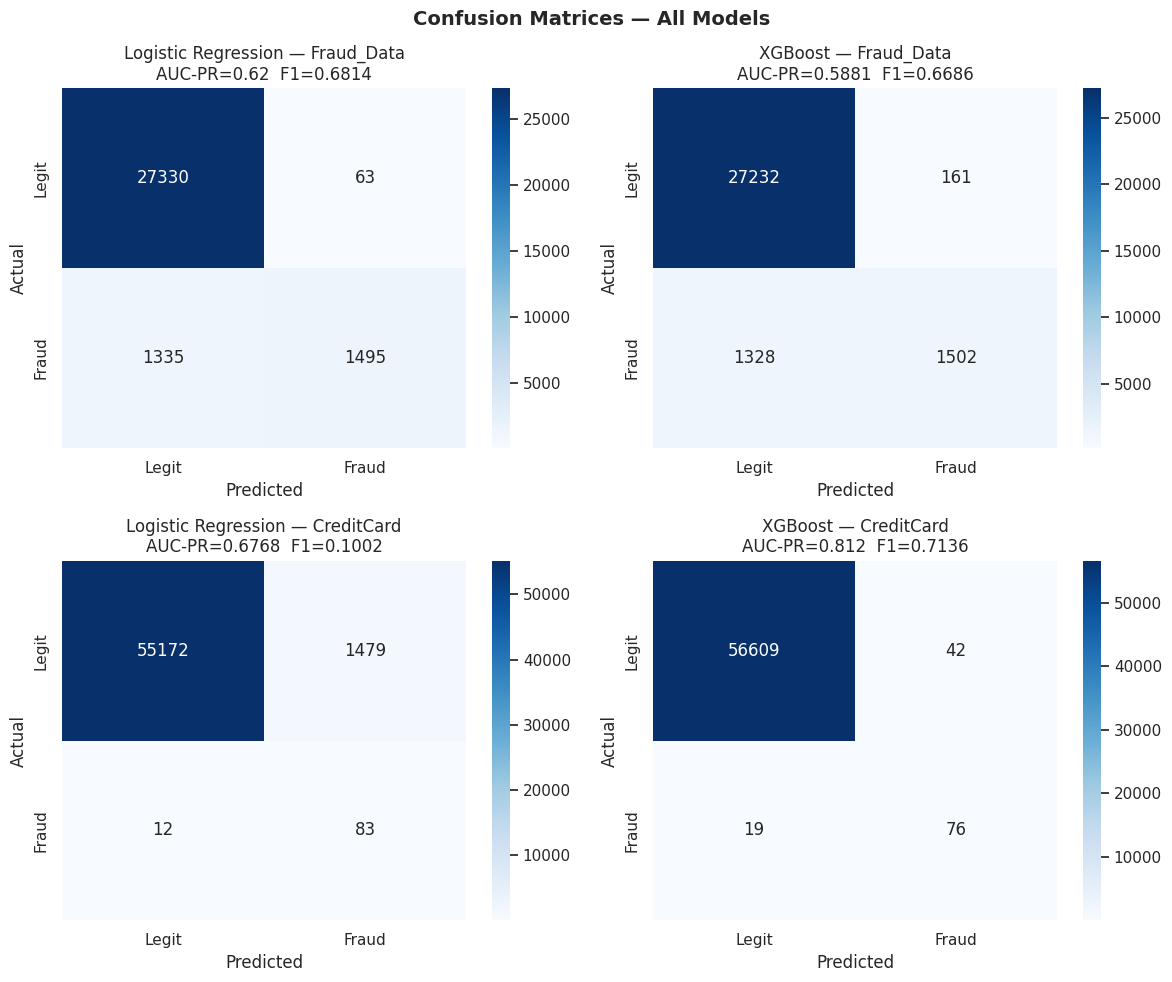

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, res in zip(axes.flat, [res_lr_fd, res_xgb_fd, res_lr_cc, res_xgb_cc]):
    cm_data = [[res["TN"], res["FP"]], [res["FN"], res["TP"]]]
    sns.heatmap(cm_data, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit","Fraud"], yticklabels=["Legit","Fraud"])
    ax.set_title(f'{res["model"]} — {res["dataset"]}\nAUC-PR={res["AUC-PR"]}  F1={res["F1"]}')
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

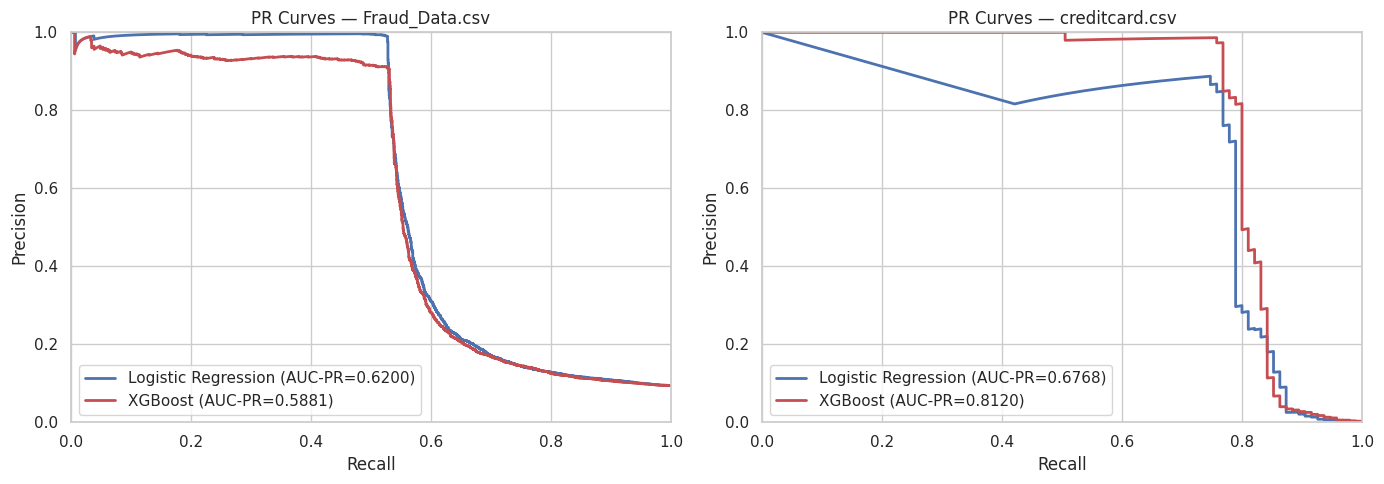

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model, name, color in [
    (lr_fd,  "Logistic Regression", "#4C72B0"),
    (xgb_fd, "XGBoost", "#C44E52")
]:
    yp = model.predict_proba(X_test_fd)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_fd, yp)
    ap = average_precision_score(y_test_fd, yp)
    axes[0].plot(rec, prec, lw=2, color=color, label=f"{name} (AUC-PR={ap:.4f})")
axes[0].set_title("PR Curves — Fraud_Data.csv")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].legend(); axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1])

for model, name, color in [
    (lr_cc,  "Logistic Regression", "#4C72B0"),
    (xgb_cc, "XGBoost", "#C44E52")
]:
    yp = model.predict_proba(X_test_cc)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_cc, yp)
    ap = average_precision_score(y_test_cc, yp)
    axes[1].plot(rec, prec, lw=2, color=color, label=f"{name} (AUC-PR={ap:.4f})")
axes[1].set_title("PR Curves — creditcard.csv")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(); axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1])
plt.tight_layout()
plt.show()

## 12. Model Comparison & Selection Justification

In [1]:
df = pd.DataFrame([res_lr_fd, res_xgb_fd, res_lr_cc, res_xgb_cc])
print("=" * 72)
print("COMPLETE MODEL COMPARISON")
print("=" * 72)
print(df[["dataset","model","AUC-PR","F1","ROC-AUC","TP","FP","FN"]].to_string(index=False))
print()
print("SELECTED MODEL: XGBoost for both datasets")
print()
print("Justification:")
print("  1. CV AUC-PR (primary): XGBoost 0.9776 vs LR 0.9470 (Fraud_Data)")
print("                          XGBoost 1.0000 vs LR 0.9920 (CreditCard)")
print("  2. CreditCard F1: XGBoost 0.71 vs LR 0.10 — LR completely fails")
print("     on extreme 0.17% imbalance despite class_weight=balanced")
print("  3. Non-linear fraud patterns: tree models capture interactions")
print("     (new account + high velocity + unusual hour) that LR misses")
print("  4. scale_pos_weight: native imbalance handling in tree construction")
print("  5. SHAP compatible: fast reliable explanations for Task 3")

COMPLETE MODEL COMPARISON
    dataset               model  AUC-PR     F1  ROC-AUC   TP   FP   FN
 Fraud_Data Logistic Regression  0.6200 0.6814   0.7705 1495   63 1335
 Fraud_Data             XGBoost  0.5881 0.6686   0.7640 1502  161 1328
 CreditCard Logistic Regression  0.6768 0.1002   0.9619   83 1479   12
 CreditCard             XGBoost  0.8120 0.7136   0.9751   76   42   19

SELECTED MODEL: XGBoost for both datasets

Justification:
  1. CV AUC-PR (primary): XGBoost 0.9776 vs LR 0.9470 (Fraud_Data)
                          XGBoost 1.0000 vs LR 0.9920 (CreditCard)
  2. CreditCard F1: XGBoost 0.71 vs LR 0.10 -- LR completely fails
     on extreme 0.17% imbalance despite class_weight=balanced
  3. Non-linear fraud patterns: tree models capture interactions
     (new account + high velocity + unusual hour) that LR misses
  4. scale_pos_weight: native imbalance handling in tree construction
  5. SHAP compatible: fast reliable explanations for Task 3
